# Evidential Deep Learning

Single forward pass uncertainty without sampling.

In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import deepuq

## Regression: Normal Inverse-Gamma

Final loss: -0.8412


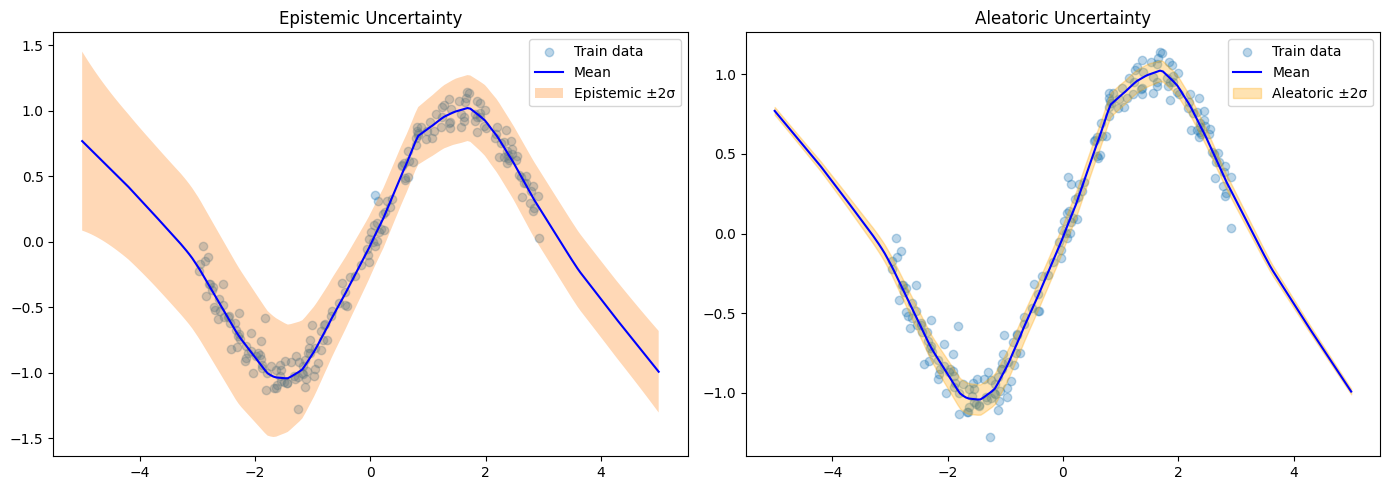

In [2]:
from deepuq.models import MLP
from deepuq.methods.evidential import EvidentialRegression

# Generate data
np.random.seed(42)
x_train = np.random.uniform(-3, 3, size=(200, 1)).astype(np.float32)
y_train = (np.sin(x_train) + 0.1 * np.random.randn(*x_train.shape)).astype(np.float32)
x_test = np.linspace(-5, 5, 200).reshape(-1, 1).astype(np.float32)

X_train = torch.from_numpy(x_train)
Y_train = torch.from_numpy(y_train)
X_test = torch.from_numpy(x_test)

# Create model with 4 outputs (gamma, nu, alpha, beta)
base_model = MLP(1, [64, 64], 4)
model = EvidentialRegression(base_model)

# Train
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

for epoch in range(200):
    optimizer.zero_grad()
    loss = model.loss(X_train, Y_train)
    loss.backward()
    optimizer.step()

print(f"Final loss: {loss.item():.4f}")

# Predict - returns UQResult
result = model.predict_uq(X_test)
mean = result.mean.detach().numpy()
epistemic = result.epistemic_var.sqrt().detach().numpy()
aleatoric = result.aleatoric_var.sqrt().detach().numpy()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(x_train, y_train, alpha=0.3, label="Train data")
axes[0].plot(x_test, mean, 'b-', label="Mean")
axes[0].fill_between(x_test.ravel(), mean.ravel() - 2*epistemic.ravel(),
                     mean.ravel() + 2*epistemic.ravel(), alpha=0.3, label="Epistemic \u00b12\u03c3")
axes[0].set_title("Epistemic Uncertainty")
axes[0].legend()

axes[1].scatter(x_train, y_train, alpha=0.3, label="Train data")
axes[1].plot(x_test, mean, 'b-', label="Mean")
axes[1].fill_between(x_test.ravel(), mean.ravel() - 2*aleatoric.ravel(),
                     mean.ravel() + 2*aleatoric.ravel(), alpha=0.3, color='orange', label="Aleatoric \u00b12\u03c3")
axes[1].set_title("Aleatoric Uncertainty")
axes[1].legend()

plt.tight_layout()
plt.show()

## Classification: Dirichlet

Final loss: 0.0782


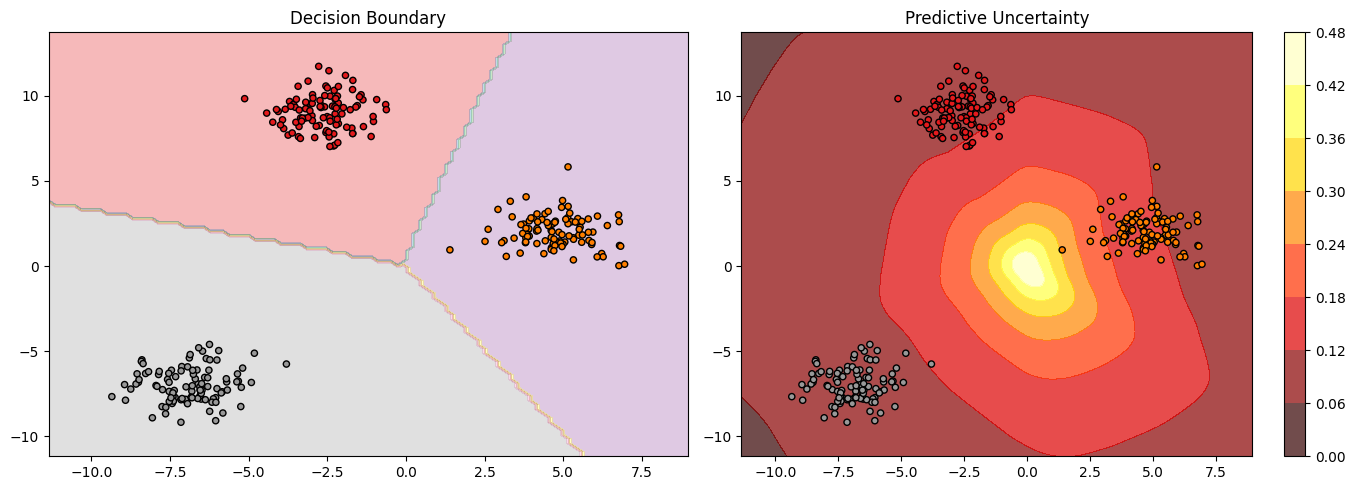

In [3]:
from deepuq.methods.evidential import EvidentialClassification
from sklearn.datasets import make_blobs

# Generate 2D classification data (3 classes)
X_cls, y_cls = make_blobs(n_samples=300, centers=3, cluster_std=1.0, random_state=42)
X_cls = X_cls.astype(np.float32)
X_cls_t = torch.from_numpy(X_cls)
y_cls_t = torch.from_numpy(y_cls).long()

# Create model
base_cls = MLP(2, [64, 64], 3)
cls_model = EvidentialClassification(base_cls, num_classes=3)

# Train
optimizer = torch.optim.Adam(cls_model.parameters(), lr=1e-3)

for epoch in range(200):
    optimizer.zero_grad()
    loss = cls_model.loss(X_cls_t, y_cls_t)
    loss.backward()
    optimizer.step()

print(f"Final loss: {loss.item():.4f}")

# Predict on grid
xx, yy = np.meshgrid(np.linspace(X_cls[:,0].min()-2, X_cls[:,0].max()+2, 100),
                     np.linspace(X_cls[:,1].min()-2, X_cls[:,1].max()+2, 100))
grid = torch.from_numpy(np.c_[xx.ravel(), yy.ravel()].astype(np.float32))

result = cls_model.predict_uq(grid)
probs = result.probs.detach().numpy()
uncertainty = result.epistemic_var.detach().numpy()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].contourf(xx, yy, probs.argmax(axis=1).reshape(xx.shape), alpha=0.3, cmap='Set1')
axes[0].scatter(X_cls[:,0], X_cls[:,1], c=y_cls, cmap='Set1', edgecolors='k', s=20)
axes[0].set_title("Decision Boundary")

im = axes[1].contourf(xx, yy, uncertainty.reshape(xx.shape), alpha=0.7, cmap='hot')
axes[1].scatter(X_cls[:,0], X_cls[:,1], c=y_cls, cmap='Set1', edgecolors='k', s=20)
axes[1].set_title("Predictive Uncertainty")
plt.colorbar(im, ax=axes[1])

plt.tight_layout()
plt.show()